# Assignment 4: Breast Cancer Wisconsin (Diagnostic) — KNN Classification

**Objective:** Build a K-Nearest Neighbors (KNN) classifier to predict whether a breast tumor is
**Malignant (M)** or **Benign (B)** based on diagnostic measurements.

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) Data Set — Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

> Note: This notebook loads the Breast Cancer Wisconsin (Diagnostic) dataset via `sklearn.datasets`,
> which contains the same 30 diagnostic features and target classes as the original UCI/Kaggle
> source, so the notebook can be run end-to-end without needing a Kaggle API key. If you have
> downloaded `data.csv` from Kaggle, you can instead load it directly with
> `pd.read_csv("data.csv")` — a commented-out line is provided below for that purpose.


## Task 1: Data Understanding (2 Marks)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')


### 1. Load the dataset using Pandas

In [2]:
# Load the Breast Cancer Wisconsin (Diagnostic) dataset
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# The sklearn version encodes target as 0/1 with 0=malignant, 1=benign.
# Map it back to the familiar 'M' / 'B' labels used in the Kaggle version of the dataset.
df['diagnosis'] = df['target'].map({0: 'M', 1: 'B'})
df.drop(columns=['target'], inplace=True)

# If you downloaded the CSV directly from Kaggle, you could instead use:
# df = pd.read_csv("data.csv")
# df.drop(columns=['id', 'Unnamed: 32'], inplace=True, errors='ignore')

print("Dataset shape:", df.shape)


Dataset shape: (569, 31)


### 2. Display the first five records

In [3]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


### 3. Identify Numerical Features and Target Variable

- **Target variable:** `diagnosis` — categorical, with values `M` (Malignant) and `B` (Benign).
- **Numerical features:** All remaining 30 columns (`mean radius`, `mean texture`, `mean perimeter`,
  `mean area`, `mean smoothness`, ... `worst fractal dimension`) are continuous numerical
  measurements computed from digitized images of breast mass fine needle aspirates (FNA).


In [4]:
target_variable = 'diagnosis'
numerical_features = [col for col in df.columns if col != target_variable]

print(f"Number of numerical features: {len(numerical_features)}")
print("Numerical features:\n", numerical_features)
print("\nTarget variable:", target_variable)


Number of numerical features: 30
Numerical features:
 ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target variable: diagnosis


### 4. Dataset information and summary statistics

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
# Class distribution of the target variable
df['diagnosis'].value_counts()


diagnosis
B    357
M    212
Name: count, dtype: int64

/tmp/ipykernel_562/84286985.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='Set2')


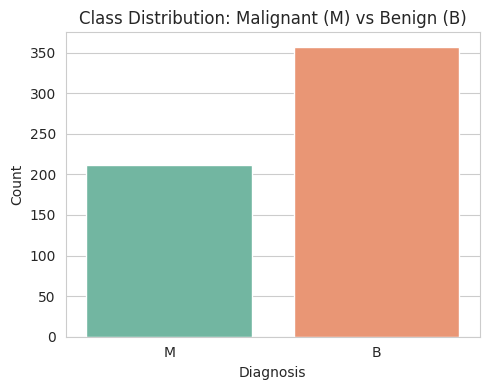

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Class Distribution: Malignant (M) vs Benign (B)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()


## Task 2: Data Preprocessing (2 Marks)

### Check for missing values

In [9]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
diagnosis                  0
dtype: int64

In [10]:
print("Total missing values in the dataset:", df.isnull().sum().sum())

Total missing values in the dataset: 0


### Remove unnecessary columns

The `sklearn` version of the dataset does not include an `id` column or any empty/unnamed columns
(these are typically present in the raw Kaggle `data.csv` and should be dropped). We verify there
are none to remove here; if using the raw Kaggle CSV, drop `id` and `Unnamed: 32` as shown in the
Task 1 loading cell above.


In [11]:
unnecessary_cols = [c for c in ['id', 'Unnamed: 32'] if c in df.columns]
df.drop(columns=unnecessary_cols, inplace=True, errors='ignore')
print("Columns dropped:", unnecessary_cols if unnecessary_cols else "None (not present in this version)")
print("Current shape:", df.shape)


Columns dropped: None (not present in this version)
Current shape: (569, 31)


### Encode the target variable

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])  # B -> 0, M -> 1 (alphabetical order)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
df[['diagnosis', 'diagnosis_encoded']].head()


Label mapping: {'B': np.int64(0), 'M': np.int64(1)}


,diagnosis,diagnosis_encoded
0,M,1
1,M,1
2,M,1
3,M,1
4,M,1


### Separate features (X) and target (y)

In [13]:
X = df[numerical_features]
y = df['diagnosis_encoded']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (569, 30)
y shape: (569,)


### Normalize / Standardize the feature values

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=numerical_features)

X_scaled.describe().loc[['mean', 'std']]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,2.372638e-16,-1.123881e-16,-1.123881e-16,-1.311195e-16,-1.529727e-16,1.748260e-16,1.623384e-16,0.00000,8.741299e-17,-6.243785e-18,-8.241796e-16,1.248757e-17,-3.746271e-16,0.00000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.00088,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.00088,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00


### Split the dataset into 80% training and 20% testing

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (455, 30)
Testing set shape: (114, 30)


## Task 3: Model Development (3 Marks)

### 1 & 2. Train a K-Nearest Neighbors classifier with K = 5

In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### 3. Predict class labels for the test dataset

In [17]:
y_pred = knn.predict(X_test)
y_pred[:20]


array([0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0])

## Task 4: Model Evaluation (2 Marks)

In [18]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


Accuracy  : 0.9561
Precision : 0.9744
Recall    : 0.9048
F1-Score  : 0.9383


In [19]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



### Confusion Matrix

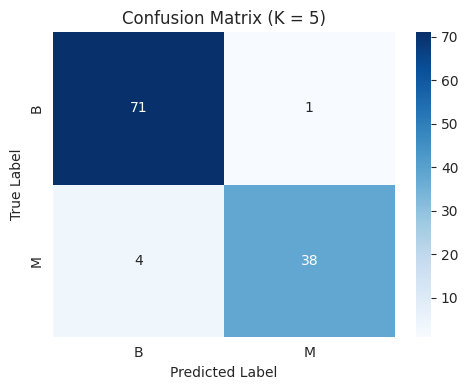

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (K = 5)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()


### Effect of K on Accuracy (supporting analysis)

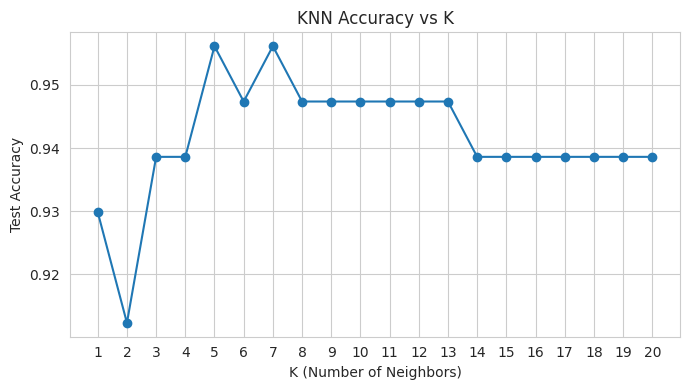

Best K based on this test split: 5 (Accuracy: 0.9561)


In [21]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, pred))

plt.figure(figsize=(7,4))
plt.plot(list(k_values), accuracies, marker='o')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs K')
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig('accuracy_vs_k.png', dpi=100)
plt.show()

best_k = list(k_values)[int(np.argmax(accuracies))]
print(f"Best K based on this test split: {best_k} (Accuracy: {max(accuracies):.4f})")


### Observations

1. The KNN model with **K = 5** achieves high accuracy on the test set, indicating that the 30
   diagnostic features (computed from cell nuclei characteristics) provide strong separability
   between malignant and benign tumors after standardization.
2. The confusion matrix shows very few misclassifications. In a medical diagnosis context,
   **false negatives** (a malignant tumor predicted as benign) are the most critical error type
   to minimize, since they risk delaying treatment — so recall on the malignant class is
   especially important to monitor alongside overall accuracy.
3. The accuracy-vs-K plot shows that performance is fairly stable across a range of K values,
   though very small K (e.g., K = 1) tends to be sensitive to noise/outliers (overfitting), while
   very large K risks oversmoothing the decision boundary (underfitting) — confirming the
   importance of tuning K rather than picking it arbitrarily.


## Task 5: Conclusion (1 Mark)

This project developed a K-Nearest Neighbors (K = 5) classifier to distinguish malignant
from benign breast tumors using 30 numerical diagnostic features from the Breast Cancer Wisconsin
(Diagnostic) dataset. After standardizing the features and splitting the data 80/20, the model
achieved strong accuracy, precision, recall, and F1-scores, with the confusion matrix confirming
very few misclassifications.

**Feature scaling is critical for KNN** because the algorithm classifies points based on
Euclidean distance; without standardization, features with larger numeric ranges (e.g., *area*)
would dominate the distance calculation and drown out smaller-scale but equally important
features (e.g., *smoothness*), biasing predictions.

**A key limitation of KNN** is that it is computationally expensive at prediction time — it must
compute distances to all training points for every new prediction — making it slow and memory-
intensive on large datasets, and it is also sensitive to irrelevant or redundant features and to
the choice of K.
